*In this blog post, I am sharing a slightly-modified version of a session for graduate students at CU Boulder on "Evaluating the amount of statistical evidence for a phenomenon".*

*It starts with a refresher on the p-value and null-hypothesis significance testing (NHST), and then offers guidelines on how to evaluate the amount of statistical evidence presented in a single study, and in a set of studies.*

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypcurve as ppc
import scipy.stats as stats
import seaborn as sns
from IPython.display import HTML, display

## A Refresher on Null-Hypothesis Significance Testing

### What is a p-value?

"The probability that a result at least as extreme as that of the testing procedure would be observed when the null hypothesis is true".

Formally, we write: $$P(X > \lvert x \rvert \mid H_0)$$

### What is the null hypothesis?

It is a set of assumptions about the data-generating mechanism of the experiment.

For instance, when comparing the means of two independent samples (i.e., a t-test), the null hypothesis is:

* "Both samples were drawn at random from the same distribution with equal mean and equal variance."

When comparing the means of several samples (i.e., an ANOVA), the null hypothesis is:
* "All samples were drawn at random from the same distribution with equal mean and equal variance."

From these assumptions, statisticians are able to derive the *theoretical distribution of the test statistics under the null*: The distribution of results that one would expect to observe when the null hypothesis is true.

### A practical example: The t-test

For instance, when the assumptions of the t-test are met, the statistics t (corresponding to the difference between groups, scaled by the standard error of the mean) follows a t-distribution with N-2 degrees of freedom:

$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_{X_1}^2+s_{X_2}^2}{N/2}}} \sim \mathcal{t}(N-2)$$

As proof, let's simulate the distribution of t-values that we would get across a very large number of simulated "experiments" in which the null hypothesis is true (i.e., both samples are drawn from an identical population):

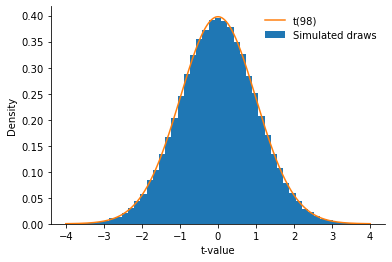

In [2]:
np.random.seed(53894034)
g1 = np.random.normal(0, 1, size=(100000, 50))  # 100,000 samples of size 50
g2 = np.random.normal(0, 1, size=(100000, 50))  # 100,000 samples of size 50
diff = (g1 - g2).mean(axis=1)  # Mean difference
tstat = diff / np.sqrt(
    (g1.std(ddof=1, axis=1) ** 2 + g2.std(ddof=1, axis=1) ** 2) / 50
)  # t-stats

# Plotting the results
fig, ax = plt.subplots(1, 1)
bins = np.linspace(-4, 4, 50)
ax.hist(tstat, bins=bins, label="Simulated draws", density=True)
x = np.linspace(-4, 4, 1000)
y = stats.t(98).pdf(x)
ax.plot(x, y, label="t(98)")
plt.legend(frameon=False)
sns.despine()
ax.set_xlabel("t-value")
ax.set_ylabel("Density")
sns.despine()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig1"))

The theoretical distribution (in orange) closely matches the results of our simulation (in blue): What is predicted to happen when the null is true corresponds to what is actually observed.

### Tying the null-hypothesis and the p-value together.

Knowing the distribution of results that we should expect to get when the null hypothesis is true is very useful: It allows us to determine whether a result obtained from an experiment is **compatible** with the null hypothesis.

Again, let's use a difference of means as an example:

In [3]:
np.random.seed(53894034)
g1 = np.random.normal(0, 1, 50)
g2 = np.random.normal(0, 1, 50)
diff = (g1 - g2).mean()
tstat = diff / np.sqrt((g1.std(ddof=1) ** 2 + g2.std(ddof=1) ** 2) / 50)
display(HTML(f"The mean difference between the two groups is {diff:.2f}"))
display(HTML(f"The t-value is {tstat:.2f}."))

How extreme is this difference? To answer this question, we can observe the theoretical distribution under the null, and check how often we would encounter a value at least that extreme as 1.27.

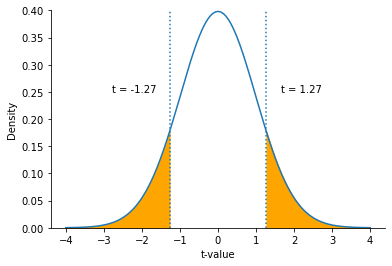

In [4]:
fig, ax = plt.subplots(1, 1)
x = np.linspace(-4, 4, 1000)
y = stats.t(98).pdf(x)
ax.plot(x, y)
ax.axvline(tstat, ls=":")
ax.annotate(f"t = {tstat:.2f}", (-2.2, 0.25), ha="center")
ax.axvline(-tstat, ls=":")
ax.annotate(f"t = {-tstat:.2f}", (2.2, 0.25), ha="center")
ax.set_xlabel("t-value")
ax.set_ylabel("Density")
ax.set_ylim(0, 0.4)
tlow = np.linspace(-4, tstat, 1000)
thigh = np.linspace(-tstat, 4, 1000)
ax.fill_between(tlow, stats.t(98).pdf(tlow), color="orange")
ax.fill_between(thigh, stats.t(98).pdf(thigh), color="orange")
sns.despine()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig2"))

In [5]:
display(
    HTML(
        f"Graphically, we see that values more extreme than {np.abs(tstat):.2f} (in absolute value) are relatively common. "
        f"In fact, we would expect to see a value more extreme {stats.t(98).cdf(tstat)*200:.1f}% "
        f"of the time. <br> We write p = {stats.t(98).cdf(tstat)*2:.3f}, and conclude that this result would not be too unexpected "
        "if the null hypothesis were true."
    )
)

## Assessing the Statistical Evidence Presented In One Study

As we have just discussed, the p-value indicates the probability of observing a result at least as extreme when the null is true.

If the p-value of a statistical test is sufficiently small (typically p < .05), researchers conclude that it is unlikely that this result emerged by chance alone[^1], and then write that the result is "statistically significant."

In the context of an experiment with two conditions (Treatment vs. Control), it would suggest that the treatment had an impact on the dependent variable.

However, **you should use caution when interpreting a p-value, and keep in mind the following:**

### The p-value is only interpretable against a well-defined null hypothesis

As I reminded earlier, the p-value is obtained by comparing the result of an experiment to a *specific* null distribution that corresponds to a *specific* null hypothesis.

When you read papers however, it is often difficult to know *which specific null hypothesis* the researchers had in mind when analyzing their data. Indeed, there are many ways one can choose to analysis one's data: Which condition(s) to compare, which dependent variable to analyze, whether to exclude anomalous responses or outliers...

In particular, [we have known since 2011 that this "analytical flexibility" (sometimes called researcher's degrees of freedom, or p-hacking) renders the p-value uninterpretable](https://doi.org/10.1177/0956797611417632): When researchers can "pick and choose" their null hypothesis after seeing the data, they will obtain false-positive results far too often.

Fortunately, there is a remedy to this ambiguity: [Pre-registration](https://doi.org/10.1002/jcpy.1208). A pre-registration is a time-stamped document in which the researcher outlines the *specific* null hypothesis that they will test in the experiment. As long as this pre-registration is sufficiently detailed (carefully outlining all relevant aspects of the data collection and analysis), and as long as the data collection and analysis follow the pre-registration, the p-value reported in the paper becomes interpretable again.

### The p-value is a continuous measure of evidence against the null

Behavioral research suffers from an unhealthy fixation on p = .05 as a "magical number," but there is nothing special about this value. It is an arbitrary statistical convention that obscures something important: The p-value is a **continuous measure of evidence**. The smaller it is, the less compatible the result is with the null hypothesis.

When reading papers, you should therefore pay attention to the p-values themselves, and not just to the fact that the results are "significant" or "not significant." All other things being equal[^2], an experiment that yields p = .001 provides stronger evidence against the null than p = .049. On the other hand, both p = .051 and p = .049 provide an equivalent (and relatively weak) amount of evidence against the null.

This is particularly important if the study is not pre-registered. Indeed, [while it is very easy to obtain p < .05 through researcher's degrees of freedom, it is much more difficult to achieve much lower p-values (e.g., p < .001)](https://doi.org/10.1037/xge0000104).

## Assessing the Statistical Evidence Presented Across Multiple Studies

Pre-registration remains an uncommon practice (although things are changing fast, and I'm hopeful that it will be the norm in a few years). For this reason, it is typically difficult to determine if a *single* p-value presents sufficient evidence against the null.

Fortunately, psychology and marketing papers often present multiple experiments, and therefore *multiple* p-values. Here, I will explain how to use the *overall distribution of these multiple p-values* to assess the amount of evidence against the null that the paper presents.

This approach is called a **[p-curve analysis](https://doi.org/10.1037/a0033242)**.

### What is a p-curve?

A p-curve is, at its core, a simple idea: It is the distribution of **p-values** that one would expect to observe, across multiple experiments, for a given level of statistical power.

In particular, the p-curve focuses on the distribution of **significant (p < .05) p-values.**

The reason is simple: If the p-value of the experiment is not significant, there is a high chance that it will not appear in the paper. On the other hand, we can be reasonably confident that people would not exclude experiments from their paper because they obtained a significant result.

### The p-curve under the null

The first p-curve we are going to cover is the p-curve under the null: The distribution of p-values that one would expect to observe when the null hypothesis is true.

It is also the simplest p-curve because it is uniform. See for yourself:

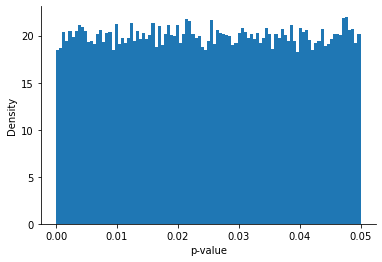

In [6]:
np.random.seed(53894034)
g1 = np.random.normal(0, 1, size=(1000000, 50))  # 1,000,000 samples of size 50
g2 = np.random.normal(0, 1, size=(1000000, 50))  # 1,000,000 samples of size 50
_, pvals = stats.ttest_ind(g1, g2, axis=1)
pvals_sig = pvals[pvals < 0.05]  # Only sig. p-values
fig, ax = plt.subplots(1)
ax.hist(pvals_sig, bins=np.linspace(0, 0.05, 100), density=True)
ax.set_xlabel("p-value")
ax.set_ylabel("Density")
sns.despine()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig3"))

Note that this result follows directly from the definition of the null hypothesis: We did not need to simulate experiments and graph their p-values to obtain this result! Here's the explanation.
* A p-value of .01 means that, when the null hypothesis is true, we will get a more extreme result 1% of the time.
    * We therefore expect that 1% of p-values will fall between 0 and .01
* A p-value of .02 means that, when the null hypothesis is true, we will get a more extreme result 2% of the time.
    * We therefore expect that 1% of p-values will fall between .01 and .02
* A p-value of .03 peans that, when the null hypothesis is true, we will get a more extreme result 3% of the time
    * By the same logic, 1% of p-values will fall between .02 and .03

And so on. This establishes that, when the null hypothesis is true, we will as often see a p-value between .01 and .02 as we will see a p-value between .04 and .05.

### The p-curve under H1 (i.e., when the null hypothesis is NOT true)

When the null-hypothesis is no longer true (e.g., when two groups are not sampled at random from the same population, and one has a higher mean than the other), we will no longer observe that the p-values are uniformly distributed on the interval (0, .05].

Let's visualize this below:

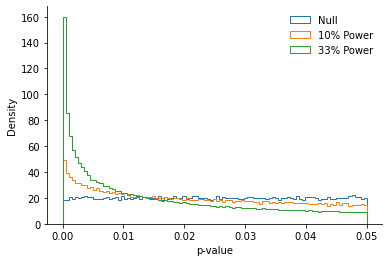

In [7]:
np.random.seed(53894034)
g1 = np.random.normal(0, 1, size=(1000000, 50))  # 1,000,000 samples of size 50
g2 = np.random.normal(0, 1, size=(1000000, 50))  # 1,000,000 samples of size 50
g3 = np.random.normal(0.15, 1, size=(1000000, 50))
g4 = np.random.normal(0.33, 1, size=(1000000, 50))
_, pvalsg1g2 = stats.ttest_ind(g1, g2, axis=1)
_, pvalsg1g3 = stats.ttest_ind(g1, g3, axis=1)
_, pvalsg1g4 = stats.ttest_ind(g1, g4, axis=1)
pvals_g1g2_sig = pvalsg1g2[pvalsg1g2 < 0.05]  # Only sig. p-values
pvals_g1g3_sig = pvalsg1g3[pvalsg1g3 < 0.05]  # Only sig. p-values
pvals_g1g4_sig = pvalsg1g4[pvalsg1g4 < 0.05]  # Only sig. p-values
fig, ax = plt.subplots(1)
ax.hist(
    pvals_g1g2_sig,
    bins=np.linspace(0, 0.05, 100),
    density=True,
    histtype="step",
    label="Null",
)
ax.hist(
    pvals_g1g3_sig,
    bins=np.linspace(0, 0.05, 100),
    density=True,
    histtype="step",
    label="10% Power",
)
ax.hist(
    pvals_g1g4_sig,
    bins=np.linspace(0, 0.05, 100),
    density=True,
    histtype="step",
    label="33% Power",
)
ax.set_xlabel("p-value")
ax.set_ylabel("Density")
plt.legend(frameon=False)
sns.despine()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig4"));

We see that the more power we have to detect the true effect, the more right-skewed the p-curve becomes. Large p-values (e.g., p = .04) become rarer and rarer, and small p-values (e.g., p < .01) become more and more common.

Again, this result is intuitive: The more power we have to detect a difference between two populations, the less compatible with the null the results of the experiment are going to be.

### The p-curve under p-hacking

Finally, there is a third type of p-curve to consider: What happens if the null hypothesis is true, but that researchers "p-hack" the findings to significance?

Here, we consider a very minor form of p-hacking: Researchers run a study with two DVs correlated at .9, and report the second DV if the first one does not reach statistical significance. The graphs below show the p-values obtained across 1,000,000 such simulated experiments.

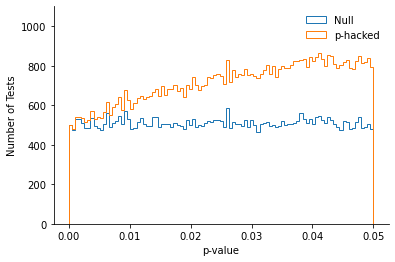

In [8]:
np.random.seed(53894034)
g1 = np.random.multivariate_normal(
    mean=[0, 0], cov=[[1, 0.9], [0.9, 1]], size=(1000000, 50)
)  # Two DVs, correlated at .9
g2 = np.random.multivariate_normal(
    mean=[0, 0], cov=[[1, 0.9], [0.9, 1]], size=(1000000, 50)
)
_, p = stats.ttest_ind(g1, g2, axis=1)  # raw p-values
phacked = np.fromiter(
    map(lambda x: x[0] if x[0] <= 0.05 else x[1], p), dtype=float
)  # Researchers p-hack
fig, ax = plt.subplots(1)
ax.hist(p[:, 0], bins=np.linspace(0, 0.05, 100), histtype="step", label="Null")
ax.hist(
    phacked, bins=np.linspace(0, 0.05, 100), histtype="step", label="p-hacked",
)
ax.set_xlabel("p-value")
ax.set_ylabel("Number of Tests")
ax.set_ylim(0, 1100)
plt.legend(frameon=False)
sns.despine()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig5"))

Here we see that the p-curve is no longer uniform: It is left-skewed!

The intuition behind this result is simple: The p-values that were slightly above .05 (e.g., .065) were "pushed" to the "significant" side, adding some weight to the left side of .05.

In these simulated experiments, we have access to all the p-values (and not only to the significant ones), so we can easily see it below:

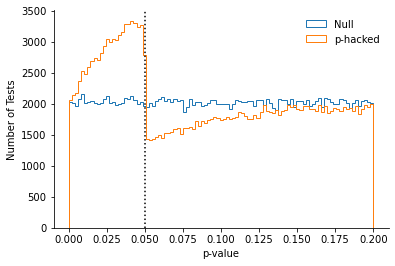

In [9]:
fig, ax = plt.subplots(1)
ax.hist(p[:, 0], bins=np.linspace(0, 0.2, 100), histtype="step", label="Null")
ax.hist(
    phacked, bins=np.linspace(0, 0.2, 100), histtype="step", label="p-hacked",
)
ax.set_xlabel("p-value")
ax.set_ylabel("Number of Tests")
ax.axvline(0.05, color="black", ls=":")
plt.legend(frameon=False)
sns.despine()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig6"))

### Using the p-curve to measure evidential value

In the same way that the *theoretical distribution under the null* can be used to evaluate the statistical significance of *one statistical test*, the p-curve can be used to evaluate the significance of a *of series of statistical tests*.

The intuition here is to compare the observed distribution of p-values to different p-curves:
* The p-curve under the null
* The p-curve of 33% power

It is very important to select the appropriate statistical results when conducting a p-curve analysis. Please refer to the [user manual](https://www.p-curve.com/guide.pdf) for more details.

Let's break down a p-curve analysis together, taking a recent paper as an example:

pypcurve v. 0.1.0 is based on Uri Simonsohn's P-Curve's app v. 4.06.



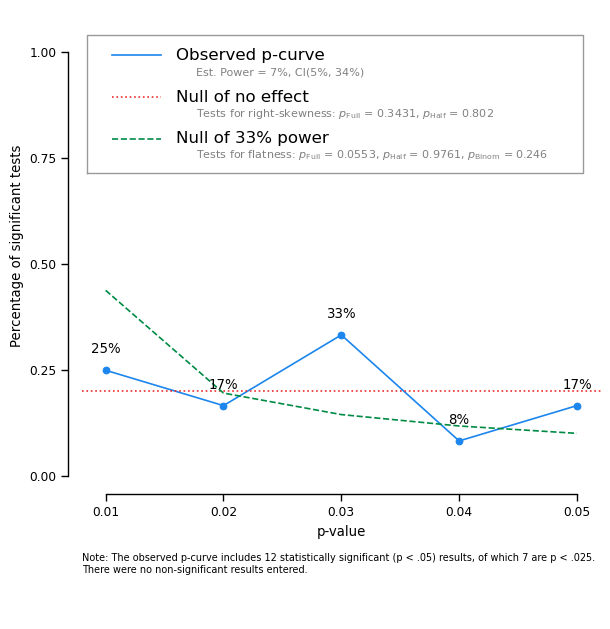

------------- Summary of p-curve tests -------------

                               Binomial Test      Continuous Test                    
                                                             Full                Half
Test of Right-Skewness            p = 0.3872  Z=-0.40, p = 0.3431   Z=0.85, p = 0.802
Test of Flatness vs. 33% Power     p = 0.246  Z=-1.60, p = 0.0553  Z=1.98, p = 0.9761


<Figure size 432x288 with 0 Axes>

In [10]:
df = pd.read_excel("Data.xlsx").dropna(subset=["Test"]).query("Title == 'A'")
pc = ppc.PCurve(df.Test)
pc.summary()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig7"));

The p-curve app displays different outputs.

1. First, we see the p-curve chart. The p-curve chart displays the following distributions:
    * In blue, we see the distribution of the p-values entered by the user on the (0, .05] interval. Any p-value greater than .05 is omitted from the analysis. Remember why?
    * In red, the expected distribution of the p-values under the null. As discussed before, it is a uniform distribution.
    * In green, the expected distribution of the p-values under H1 of 33% power. As discussed before, it is slightly right-skewed: Large p-values are expected to be rarer than small p-values.


2. Then, we see that the p-curve app returns a list of "p-curve tests". Again, let's break them down:
   * The "Tests of right-skewness" compare the actual distribution of the p-values to the expected distribution under the null (the uniform distribution) in three different ways:
       * The binomial test compares the proportion of p-values lower than .025 to the proportion of p-values higher than .025. If it is significantly greater than 50%, it means that the actual distribution is more right-skewed than the uniform distribution.
       * The continuous tests use the Stouffers' method to see if the test statistics are compatible with what would be expected under the null. They come in two flavors: The "Full" test takes all the p-values into account, and the "Half" test only takes the p-values smaller than .025.
   * The "Tests of Flatness vs. 33% Power" compare the actual distribution of the p-values to the expected distribution when the research has 33% power to detect the effect.

Here, you can see that the p-curve for this paper does not look great: It looks flat (i.e., consistent with the null being true). In addition, the text output shows that we cannot reject the null of no effect, and the estimated power is very low (7%).

This should give us little confidence in the phenomenon described in the paper: The experiments do not have nearly enough power to detect the phenomenon (if the phenomenon exists).

Let's look at a second paper now.

pypcurve v. 0.1.0 is based on Uri Simonsohn's P-Curve's app v. 4.06.



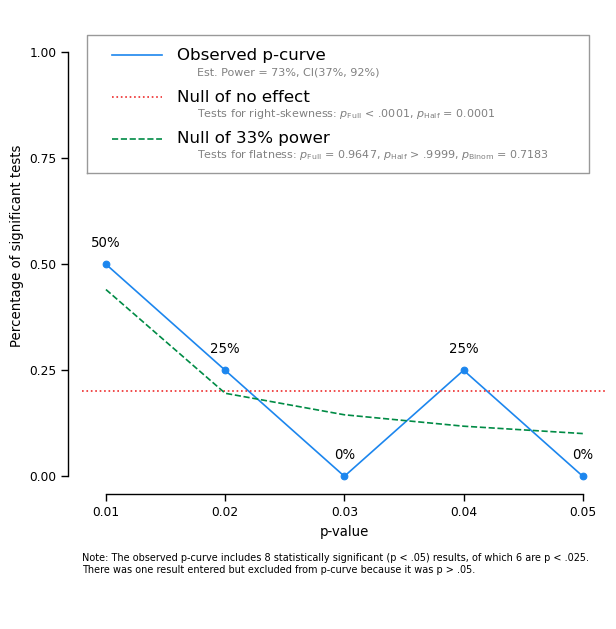

------------- Summary of p-curve tests -------------

                               Binomial Test     Continuous Test                     
                                                            Full                 Half
Test of Right-Skewness            p = 0.1445  Z=-3.89, p < .0001  Z=-3.67, p = 0.0001
Test of Flatness vs. 33% Power    p = 0.7183  Z=1.81, p = 0.9647    Z=4.04, p > .9999


<Figure size 432x288 with 0 Axes>

In [11]:
title = "B"
df = pd.read_excel("Data.xlsx").dropna(subset=["Test"]).query("Title == @title")
pc = ppc.PCurve(df.Test)
pc.summary()
fig = plt.gcf()
plt.close()
display(fig, metadata=dict(filename="Fig8"));

This one looks much better! The p-curve is appropriately right-skewed, and the estimated power is high. This should give us confidence that the phenomenon reported in the paper would replicate.

## Conclusions

Being able to judge the quality of statistical evidence presented in a paper is an important skill for graduate students: It is something that will help you get a sense of which results that are likely to replicate, and will help you select a fruitful research area.

When reading papers, I suggest you apply the following mental checklist:
* Are the studies pre-registered, and are the pre-registrations sufficiently precise? If yes, are the reported methods and analysis consistent with the pre-registration? If not, are the deviations acknowledged and justified?
* How is the distribution of p-values? If they are all large (e.g., all p between .01 and .05), what are the conclusions of a p-curve analysis?

Finally, keep in mind that evidential value is not the only aspect of a paper: Having sufficient evidential value in the studies does not mean that the experiments are internally valid, that the problem studied is interesting, or that the paper makes a contribution to the literature. I would nonetheless argue that it is a crucial aspect: If a paper has a provocative theory, clever experiments, but has no evidential value, then it is unclear what we are supposed to learn from the experiments reported in the paper...

[^1]: As reminded by [Daniël Lakens](https://twitter.com/lakens/status/1428934747271671808?s=20), this interpretation is, in fact, erroneous: We can only say that if the null is true, a result this extreme would only be observed p% of the time. To understand why this phrasing is erroneous, consider an experiment in which the null is true: p < .05 would be observed 5% of the time, but the null will be true every time.

[^2]: As pointed out by [Shilaan Alzahawi](https://twitter.com/shilaan01/status/1428896658662649867?s=20), the "all other things being equal" is important, because it is no longer true when two studies have very different samples sizes. For instance, finding p = .04 with N = 50 would be stronger evidence than p = .03 in with N = 1,000,000. The argument is a bit too complex to be laid out here, but it has to do with the differences in statistical power: Since a study with a million participants has a lot of statistical power to detect even very small effects, getting p = .03 is more consistent with the null than with other alternatives.
